# Import

In [1]:
# POET-PRVM, OLS, EWMA, LASSO, HLASSO, HAR-DRD, HAR-DRD-LOG test in Crypto Market
# 가상환경 : COIN_FIVAR

In [ ]:
! pip install tqdm
! pip install tqdm-joblib
! pip install cvxpy

In [63]:
import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

import os
import math
from datetime import date
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt


from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
import cvxpy as cp

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed

np.set_printoptions(precision=8, suppress=False, linewidth=100)
warnings.filterwarnings("ignore")

# Settings

In [ ]:
# PRVM 불러올 경로
PRVM_OUTPUT_DIR = "crypto_prvm_output"

# 결과 저장할 경로
FIVAR_OUTPUT_DIR = "crypto_fivar_HAR_output"
os.makedirs(FIVAR_OUTPUT_DIR, exist_ok=True)

# PRVM 불러오기
loaded = np.load(f"{PRVM_OUTPUT_DIR}/prvm_gamma_jv_2023_2025_top200.npz", allow_pickle=True,)

# PRVM, JV 정의
Gamma_array = loaded["Gamma_trunc_psd"]   # continuous PRVM
Gamma_untrunc_array = loaded["Gamma_untrunc_psd"]
JV_array = loaded["JV_raw"]
total_dates = pd.to_datetime(loaded["days"])

PRVM = Gamma_array.astype(np.float64)
JV_array = JV_array.astype(np.float64)

T = PRVM.shape[0]
p = PRVM.shape[1]

# Shape check
print(list(loaded.keys()))
print("---")
print("PRVM shape:",PRVM.shape)
print("Jump shape:",JV_array.shape)
print("Date:", total_dates.min(),"-", total_dates.max())

['Gamma_trunc_raw', 'Gamma_untrunc_raw', 'JV_raw', 'Gamma_trunc_psd', 'Gamma_untrunc_psd', 'days']
---
PRVM shape: (1095, 200, 200)
Jump shape: (1095, 200, 200)
Date: 2023-01-01 00:00:00 - 2025-12-31 00:00:00


In [65]:
n = 365              # rolling window length
pred_T = T - n       # number of forecasts
L = 30               # recent average window for eigenvectors
r = 3                # number of common factors
h = 1                # VAR lag
one_year = 365

week_lag = 7
month_lag = 30
# n_obs = n - month_lag

print("T:", T)
print("p:", p)
print("pred_T:", pred_T)

T: 1095
p: 200
pred_T: 730


# -----[Utility functions]-----

## Utility function

In [66]:
def eigen_decompose(matrix):
    eigvals, eigvecs = np.linalg.eigh(matrix)
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvals = eigvals[sorted_indices]
    eigvecs = eigvecs[:, sorted_indices]
    return eigvals, eigvecs

def eigen_decompose_matrices(matrices): # shape : (n, p, p)
    eigvals_matrices = []
    eigvecs_matrices = []
    for matrix in matrices:
        eigvals, eigvecs = eigen_decompose(matrix)
        eigvals_matrices.append(eigvals)
        eigvecs_matrices.append(eigvecs)
    eigvals_matrices = np.array(eigvals_matrices) # shape : (n, p)
    eigvecs_matrices = np.array(eigvecs_matrices) # shape : (n, p, p)
    return eigvals_matrices, eigvecs_matrices

def project_to_psd(matrix, eps):
    eigvals, eigvecs = eigen_decompose(matrix)
    eigvals_thr = np.maximum(eigvals, eps)  # thresholded eigenvalues
    matrix_psd = eigvecs @ np.diag(eigvals_thr) @ eigvecs.T
    return matrix_psd, eigvals_thr, eigvecs

# # 안정화 추가코드
# def project_to_psd_portfolio(G, floor_ratio=1e-4):
#     G = 0.5 * (G + G.T)
#     eps = floor_ratio * np.trace(G) / G.shape[0]
#     G_psd, _, _ = project_to_psd(G, eps)
#     return G_psd

# trace에 의존하지 않고 양수 보장 psd
def project_to_psd_portfolio(G, floor_ratio=1e-4, abs_floor=1e-12):
    G = 0.5 * (G + G.T)
    p = G.shape[0]
    tr = np.trace(G)
    # trace 부호에 의존하지 않는 양수 floor
    eps = max(floor_ratio * abs(tr) / p, abs_floor)
    G_psd, _, _ = project_to_psd(G, eps)
    return G_psd

## Threshold 

In [ ]:
# soft thresholding
# Corresponds to R function S.Threshold(RV, T)



def decompose_factor_sparse(PRVM_day, r):

    G = np.asarray(PRVM_day, dtype=np.float64)
    G = 0.5 * (G + G.T)

    eigvals, eigvecs = eigen_decompose(G)

    Q = eigvecs[:, :r]
    Lambda = eigvals[:r]

    Theta_hat = (Q * Lambda) @ Q.T
    Theta_hat = 0.5 * (Theta_hat + Theta_hat.T)

    Sigma_tilde = G - Theta_hat
    Sigma_tilde = 0.5 * (Sigma_tilde + Sigma_tilde.T)

    return Theta_hat, Sigma_tilde


def soft_threshold(RV, T):

    RV = np.asarray(RV, dtype=np.float64)
    T = np.asarray(T, dtype=np.float64)

    RV = 0.5 * (RV + RV.T)

    T_RV = (RV - np.sign(RV) * T) * (np.abs(RV) >= T)

    diag_pos = np.maximum(np.diag(RV), 0.0)
    np.fill_diagonal(T_RV, diag_pos)

    T_RV = 0.5 * (T_RV + T_RV.T)

    return T_RV

def adaptive_threshold_scale(Sigma_tilde, eps=1e-12):

    diag_pos = np.maximum(np.diag(Sigma_tilde), 0.0)
    scale = np.sqrt(np.outer(diag_pos, diag_pos) + eps)

    return scale

In [ ]:
# Estimate one fixed threshold parameter x_hat using in-sample next-day MSPE
# 과거 데이터를 이용해 내일의 변동성 예측 오차(MSPE)를 최소화하는 최적의 단일 임계값 파라미터(x_hat)를 추정.

def estimate_in_sample_varpi(
    PRVM_insample,          # PRVM
    r,                      # factor
    varpi_bounds=(0.0, 5.0),    # x 탐색 범위
    eps=1e-12               
):

    PRVM_insample = np.asarray(PRVM_insample, dtype=np.float64)
    n_in, p_, _ = PRVM_insample.shape

    Sigma_list = []
    scale_list = []     # 임계값 적용 시 기준이 될 가중치(Scale) 저장

    # Decompose all in-sample PRVM matrices first
    for t in range(n_in):
        _, Sigma_tilde = decompose_factor_sparse(PRVM_insample[t], r)

        scale_t = adaptive_threshold_scale(
            Sigma_tilde,
            eps=eps
        )

        Sigma_list.append(Sigma_tilde)
        scale_list.append(scale_t)

    def objective(varpi):
        loss = 0.0

        for t in range(n_in - 1):
            Sigma_tilde_t = Sigma_list[t]
            Sigma_tilde_next = Sigma_list[t + 1]

            threshold_matrix = varpi * scale_list[t]

            sparse_thresholded = soft_threshold(
                Sigma_tilde_t,
                threshold_matrix
            )

            diff = sparse_thresholded - Sigma_tilde_next

            loss += np.sum(diff ** 2)

        return loss / (n_in - 1)

    res = minimize_scalar(
        objective,
        bounds=varpi_bounds,
        method="bounded"
    )

    varpi_hat = float(res.x)
    obj_min = float(res.fun)

    return varpi_hat, obj_min

In [ ]:
# Apply fixed in-sample threshold x_hat to all days
def build_poet_series_with_fixed_varpi(
    PRVM_array,
    r,
    varpi_hat,
    eps=0.0
):

    PRVM_array = np.asarray(PRVM_array, dtype=np.float64)

    T_, p_, _ = PRVM_array.shape

    POET_PRVM = np.empty_like(PRVM_array, dtype=np.float64)
    factor_PRVM = np.empty_like(PRVM_array, dtype=np.float64)
    sparse_PRVM = np.empty_like(PRVM_array, dtype=np.float64)

    for t in tqdm(range(T_), desc="Building POET PRVM with fixed varpi"):

        Theta_hat, Sigma_tilde = decompose_factor_sparse(
            PRVM_array[t],
            r
        )

        scale_t = adaptive_threshold_scale(
            Sigma_tilde,
            eps=eps
        )

        sparse_hat = soft_threshold(
            Sigma_tilde,
            varpi_hat * scale_t
        )

        poet_hat = Theta_hat + sparse_hat
        poet_hat = 0.5 * (poet_hat + poet_hat.T)

        factor_PRVM[t] = Theta_hat
        sparse_PRVM[t] = sparse_hat
        POET_PRVM[t] = poet_hat

    return POET_PRVM, factor_PRVM, sparse_PRVM

## Factor, Idio Decomposition

In [70]:
# # PRVM을 Factor와 Idio로 나누기
# raw_idio_PRVM, raw_factor_PRVM = remove_top_r_factor_each_day(PRVM, r=r)

# # Save
# raw_idio_path = f"{FIVAR_OUTPUT_DIR}/raw_idio_PRVM_top{r}_factor_removed.npy"
# raw_factor_path = f"{FIVAR_OUTPUT_DIR}/raw_factor_PRVM_top{r}.npy"

# np.save(raw_idio_path, raw_idio_PRVM)
# np.save(raw_factor_path, raw_factor_PRVM)

# print("raw_idio_PRVM shape:", raw_idio_PRVM.shape)
# print("raw_factor_PRVM shape:", raw_factor_PRVM.shape)

In [ ]:
# save
PRVM_insample = PRVM[:n]

# In sample에서 최적 임계값 찾기
varpi_hat, obj_min = estimate_in_sample_varpi(
    PRVM_insample=PRVM_insample,
    r=r,
    varpi_bounds=(0.0, 5.0)
)

print("Estimated in-sample x_hat:", varpi_hat)       # 최적의 임계값 x
print("In-sample threshold objective:", obj_min)  # 그 때의 오차값

# Full sample에서 최적값 적용
POET_PRVM, factor_PRVM, sparse_PRVM = build_poet_series_with_fixed_varpi(
    PRVM_array=PRVM,
    r=r,
    varpi_hat=varpi_hat,
    eps=1e-12
)

np.save(
    f"{FIVAR_OUTPUT_DIR}/POET_PRVM.npy",            # POET-PRVM
    POET_PRVM
)

np.save(
    f"{FIVAR_OUTPUT_DIR}/factor_PRVM.npy",          # PRVM에서 추출한 factor part
    factor_PRVM
)

np.save(
    f"{FIVAR_OUTPUT_DIR}/sparse_idio_PRVM.npy",     # PRVM에서 추출한 idio part + POET
    sparse_PRVM
)

np.save(
    f"{FIVAR_OUTPUT_DIR}/x_hat_fixed_insample.npy", # Thresholding 임계값 x
    np.array([varpi_hat, obj_min])
)

print("POET_PRVM shape:", POET_PRVM.shape)
print("factor_PRVM shape:", factor_PRVM.shape)
print("sparse_PRVM shape:", sparse_PRVM.shape)

Estimated in-sample x_hat: 4.999996371653228
In-sample threshold objective: 0.02620965489728006


Building POET PRVM with fixed in-sample x: 100%|██████████| 1095/1095 [00:07<00:00, 150.70it/s]


POET_PRVM shape: (1095, 200, 200)
factor_PRVM shape: (1095, 200, 200)
sparse_PRVM shape: (1095, 200, 200)


# -----[FIVAR]------

## Functions

In [72]:
def compute_eigvals_factor(PRVM, eigvecs_factor): # get_xi (factor)
    T = PRVM.shape[0]
    eigvals_factor = np.zeros((T, r))

    for d in range(T):
        PRVM_d = PRVM[d]

        temp_F = eigvecs_factor.T @ PRVM_d @ eigvecs_factor
        eigvals_factor[d] = np.diag(temp_F) / p
    
    return eigvals_factor # (T, r)

def compute_eigvals_idio(idio_PRVM, eigvecs_idio): # get_xi (idio)
    T = idio_PRVM.shape[0]
    eigvals_idio = np.zeros((T, p))

    for d in range(T):
        idio_PRVM_d = idio_PRVM[d]

        temp_I = eigvecs_idio.T @ idio_PRVM_d @ eigvecs_idio
        eigvals_idio[d] = np.diag(temp_I)
    
    return eigvals_idio # (T, p)

def get_eigvals_hat(eigvals_factor, eigvals_idio):
    return np.concatenate([eigvals_factor, eigvals_idio], axis=1)

def truncate(x, varpi):
    return np.clip(x, -varpi, varpi)

def get_X_factor(eigvals_factor, n):
    X_factor = []
    for d in range(h, n):
        stacked = [1]
        for k in range(h):
            stacked.extend(eigvals_factor[d - k - 1, :r])
        X_factor.append(stacked)
    X_factor = np.array(X_factor)
    return X_factor # (n-h, hr+1)

def get_X_idio(eigvals_hat, n):
    X_idio = []
    for d in range(h, n):
        stacked = [1]
        for k in range(h):
            stacked.extend(eigvals_hat[d - k - 1])
        X_idio.append(stacked)
    
    X_idio = np.array(X_idio)
    return X_idio # (n-h, h*(r+p)+1)

def standardize(matrix):
    row_means = np.mean(matrix, axis=0, keepdims=True)
    row_stds = np.std(matrix, axis=0, ddof=0, keepdims=True)
    return (matrix - row_means) / row_stds

# 분산이 0인 열이 존재할때 (모든 데이터 값이 똑같은 열)
# def standardize(matrix, eps=1e-12):
#     means = np.mean(matrix, axis=0, keepdims=True)
#     stds = np.std(matrix, axis=0, ddof=0, keepdims=True)
#     stds = np.where(stds < eps, 1.0, stds)
#     return (matrix - means) / stds

In [73]:
class CustomSGDRegressor(SGDRegressor):
    def __init__(self,
                 coef_init=None,
                 intercept_init=None,
                 loss="squared_error",
                 penalty="l2",
                 alpha=0.0001,
                 l1_ratio=0.15,
                 fit_intercept=True,
                 max_iter=1000,
                 tol=1e-3,
                 shuffle=True,
                 verbose=0,
                 epsilon=0.1,
                 random_state=None,
                 learning_rate="invscaling",
                 eta0=0.01,
                 power_t=0.25,
                 early_stopping=False,
                 validation_fraction=0.1,
                 n_iter_no_change=5,
                 warm_start=False,
                 average=False):

        super().__init__(
            loss=loss, penalty=penalty, alpha=alpha, l1_ratio=l1_ratio,
            fit_intercept=fit_intercept, max_iter=max_iter, tol=tol,
            shuffle=shuffle, verbose=verbose, epsilon=epsilon,
            random_state=random_state, learning_rate=learning_rate,
            eta0=eta0, power_t=power_t, early_stopping=early_stopping,
            validation_fraction=validation_fraction,
            n_iter_no_change=n_iter_no_change,
            warm_start=warm_start, average=average
        )
        self.coef_init = coef_init
        self.intercept_init = intercept_init
        # _initialized, _initialize 완전히 제거

    def fit(self, X, y, sample_weight=None):
        return super().fit(
            X, y,
            sample_weight=sample_weight,
            coef_init=self.coef_init,
            intercept_init=self.intercept_init
        )

    def partial_fit(self, X, y, sample_weight=None):
        coef_init = self.coef_init if not hasattr(self, 'coef_') else None
        intercept_init = self.intercept_init if not hasattr(self, 'coef_') else None
        return super().partial_fit(
            X, y,
            sample_weight=sample_weight,
            coef_init=coef_init,
            intercept_init=intercept_init
        )

## Factor Beta

In [74]:
# Fivar
def estimate_beta_F_H_LASSO(beta_init_F, eigvals_factor, tau_F, varpi_F, n, random_state=42):
    beta_init_F_safe = np.array(beta_init_F, copy=True)

    X = get_X_factor(eigvals_factor, n)  # (n-h, hr+1), 첫 열=1
    X_thresholded = truncate(X[:, 1:], varpi_F)  # feature만 truncation
    scale = 1 / (np.quantile(np.abs(X_thresholded), 0.99)+1e-10)
    X_scaled = np.hstack([np.ones((X_thresholded.shape[0], 1)), X_thresholded * scale])

    betas = []
    for i in range(r):
        y = eigvals_factor[h:n, i].ravel()
        y_scaled = y * scale
        beta_i_init = beta_init_F_safe[i].copy()

        model = CustomSGDRegressor(
            coef_init=beta_i_init.copy(),
            intercept_init=None,
            loss='huber',
            penalty=None,
            fit_intercept=False,
            epsilon=tau_F,
            max_iter=50000,
            tol=1e-10,
            random_state=random_state
        )
        model.fit(X_scaled, y_scaled)
        betas.append(model.coef_.copy())

    betas = np.array(betas)
    betas[:, 0] = betas[:, 0] * (1/scale)
    return betas

# Lasso
def estimate_beta_F_LASSO(beta_init_F, eigvals_factor, n, random_state=42):
    beta_init_F_safe = np.array(beta_init_F, copy=True)

    X = get_X_factor(eigvals_factor, n)  # (n-h, hr+1), 첫 열=1 포함

    X_feat = X[:, 1:]  # feature만
    scaler_X = StandardScaler()
    X_feat_scaled = scaler_X.fit_transform(X_feat)
    X_scaled = np.hstack([np.ones((X_feat_scaled.shape[0], 1)), X_feat_scaled])  # 첫 열 1 복원

    betas = []
    for i in range(r):
        y = eigvals_factor[h:n, i].ravel()
        scaler_y = StandardScaler()
        y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

        beta_i_init = beta_init_F_safe[i].copy()  # (hr+1,)

        model = CustomSGDRegressor(
            coef_init=beta_i_init.copy(),
            intercept_init=None,
            loss='squared_error',
            penalty=None,
            fit_intercept=False,
            max_iter=50000,
            tol=1e-10,
            random_state=random_state
        )
        model.fit(X_scaled, y_scaled)

        sy = scaler_y.scale_[0];  my = scaler_y.mean_[0]
        sx = np.concatenate([[1.0], scaler_X.scale_])
        mx = np.concatenate([[0.0], scaler_X.mean_])

        coef_orig = sy * model.coef_ / sx
        coef_orig[0] = sy * model.coef_[0] + my - np.dot(sy * model.coef_[1:] / scaler_X.scale_, scaler_X.mean_)

        betas.append(coef_orig)

    return np.array(betas)  # (r, hr+1)

# OLS
def estimate_beta_F_OLS(eigvals_factor, n):
    X = get_X_factor(eigvals_factor, n)  # (n-h, hr+1)

    betas = []
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)   # 여기가 진짜 inverse

    for i in range(r):
        y = eigvals_factor[h:n, i].ravel()

        beta_i = XtX_inv @ X.T @ y   # (XᵀX)⁻¹ Xᵀ y
        betas.append(beta_i)

    betas = np.array(betas)

    return betas   # (r, hr+1)

## Idio Beta

In [75]:
# Fivar
def grid_search_bic_H_LASSO(
    X,
    y,
    beta_init,
    tau_I,
    n,
    c_eta_grid,
    random_state=42
):

    beta_init_safe = np.array(beta_init, copy=True)
    scale_factor = (np.log(p) / n) ** 0.5

    bic_values = []
    models = []

    for c_eta in c_eta_grid:
        eta = c_eta * scale_factor

        model = CustomSGDRegressor(
            coef_init=beta_init_safe.copy(),
            intercept_init=None,
            loss='huber',
            penalty='l1',
            alpha=eta,
            epsilon=tau_I,
            fit_intercept=False,
            max_iter=10000,
            tol=1e-10,
            random_state=random_state
        )

        model.fit(X, y)

        y_pred = model.predict(X)
        rss = np.sum((y - y_pred) ** 2)

        # 수치적으로 rss=0 방지
        rss = max(rss, 1e-12)

        dfree = np.sum(model.coef_[1:] != 0)

        bic = (n - h) * np.log(rss / (n - h)) + dfree * np.log(n - h)

        bic_values.append(bic)
        models.append(model)

    bic_values = np.asarray(bic_values)

    best_idx = np.argmin(bic_values)
    best_c_eta = float(c_eta_grid[best_idx])
    best_eta = best_c_eta * scale_factor
    best_bic = float(bic_values[best_idx])

    return best_c_eta, best_eta, best_bic, bic_values

def estimate_beta_I_H_LASSO(
    beta_init_I,
    eigvals_hat,
    tau_I,
    varpi_I,
    n,
    c_eta_grid=None,
    random_state=42
):
    beta_init_I_safe = np.array(beta_init_I, copy=True)

    eigvals_standardized = standardize(eigvals_hat)
    X = get_X_idio(eigvals_standardized, n)

    # H-LASSO: feature truncation
    X_feat = truncate(X[:, 1:], varpi_I)
    X = np.hstack([np.ones((X_feat.shape[0], 1)), X_feat])

    if c_eta_grid is None:
        c_eta_grid = np.logspace(np.log10(0.1), np.log10(20.0), 30)

    best_betas = []
    best_c_etas = []
    best_etas = []
    best_bics = []
    all_bic_values = []

    for i in range(r, r + p):
        y = eigvals_standardized[h:n, i].ravel()
        beta_i_init = beta_init_I_safe[i - r].copy()

        best_c_eta, best_eta, best_bic, bic_values = grid_search_bic_H_LASSO(
            X=X,
            y=y,
            beta_init=beta_i_init,
            tau_I=tau_I,
            n=n,
            c_eta_grid=c_eta_grid,
            random_state=random_state
        )

        final_model = CustomSGDRegressor(
            coef_init=beta_i_init.copy(),
            intercept_init=None,
            loss='huber',
            penalty='l1',
            alpha=best_eta,
            epsilon=tau_I,
            fit_intercept=False,
            max_iter=20000,
            tol=1e-10,
            random_state=random_state
        )

        final_model.fit(X, y)

        best_betas.append(final_model.coef_.copy())
        best_c_etas.append(best_c_eta)
        best_etas.append(best_eta)
        best_bics.append(best_bic)
        all_bic_values.append(bic_values)

    return (
        np.array(best_betas),
        np.array(best_c_etas),
        np.array(best_etas),
        np.array(best_bics),
        np.array(all_bic_values)
    )

# LASSO
def grid_search_bic_LASSO(
    X_scaled,
    y_scaled,
    beta_init,
    n,
    c_eta_grid,
    random_state=42
):

    beta_init_safe = np.array(beta_init, copy=True)
    scale_factor = (np.log(p) / n) ** 0.5

    bic_values = []

    for c_eta in c_eta_grid:
        eta = c_eta * scale_factor

        model = CustomSGDRegressor(
            coef_init=beta_init_safe.copy(),
            intercept_init=None,
            loss='squared_error',
            penalty='l1',
            alpha=eta,
            fit_intercept=False,
            max_iter=10000,
            tol=1e-10,
            random_state=random_state
        )

        model.fit(X_scaled, y_scaled)

        y_pred = model.predict(X_scaled)
        rss = np.sum((y_scaled - y_pred) ** 2)

        rss = max(rss, 1e-12)

        dfree = np.sum(model.coef_[1:] != 0)

        bic = (n - h) * np.log(rss / (n - h)) + dfree * np.log(n - h)

        bic_values.append(bic)

    bic_values = np.asarray(bic_values)

    best_idx = np.argmin(bic_values)
    best_c_eta = float(c_eta_grid[best_idx])
    best_eta = best_c_eta * scale_factor
    best_bic = float(bic_values[best_idx])

    return best_c_eta, best_eta, best_bic, bic_values

def estimate_beta_I_LASSO(
    beta_init_I,
    eigvals_hat,
    n,
    c_eta_grid=None,
    random_state=42
):
    beta_init_I_safe = np.array(beta_init_I, copy=True)

    eigvals_standardized = standardize(eigvals_hat)
    X = get_X_idio(eigvals_standardized, n)

    X_feat = X[:, 1:]
    scaler_X = StandardScaler()
    X_feat_scaled = scaler_X.fit_transform(X_feat)

    X_scaled = np.hstack([
        np.ones((X_feat_scaled.shape[0], 1)),
        X_feat_scaled
    ])

    if c_eta_grid is None:
        # c_eta_grid = np.logspace(np.log10(0.5), np.log10(50.0), 20)
        c_eta_grid = np.logspace(np.log10(0.1), np.log10(20.0), 30)

    best_betas = []
    best_c_etas = []
    best_etas = []
    best_bics = []
    all_bic_values = []

    for i in range(r, r + p):
        y = eigvals_standardized[h:n, i].ravel()

        scaler_y = StandardScaler()
        y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

        beta_i_init = beta_init_I_safe[i - r].copy()

        best_c_eta, best_eta, best_bic, bic_values = grid_search_bic_LASSO(
            X_scaled=X_scaled,
            y_scaled=y_scaled,
            beta_init=beta_i_init,
            n=n,
            c_eta_grid=c_eta_grid,
            random_state=random_state
        )

        final_model = CustomSGDRegressor(
            coef_init=beta_i_init.copy(),
            intercept_init=None,
            loss='squared_error',
            penalty='l1',
            alpha=best_eta,
            fit_intercept=False,
            max_iter=20000,
            tol=1e-10,
            random_state=random_state
        )

        final_model.fit(X_scaled, y_scaled)

        # scaled coefficient -> original scale
        sy = scaler_y.scale_[0]
        my = scaler_y.mean_[0]

        coef_orig = sy * final_model.coef_ / np.concatenate([[1.0], scaler_X.scale_])

        coef_orig[0] = (
            sy * final_model.coef_[0]
            + my
            - np.dot(
                sy * final_model.coef_[1:] / scaler_X.scale_,
                scaler_X.mean_
            )
        )

        best_betas.append(coef_orig)
        best_c_etas.append(best_c_eta)
        best_etas.append(best_eta)
        best_bics.append(best_bic)
        all_bic_values.append(bic_values)

    return (
        np.array(best_betas),
        np.array(best_c_etas),
        np.array(best_etas),
        np.array(best_bics),
        np.array(all_bic_values)
    )

# -----[HAR-DRD]------

## Functions

In [76]:
# HAR-DRD / HAR-DRD-LOG 

# Split a covariance into variance diagonal matrix (here, variance vector) D and correlation matrix R
def decompose_drd(Gamma, var_floor=1e-12):
    
    Gamma = 0.5 * (Gamma + Gamma.T)
    D = np.maximum(np.diag(Gamma).copy(), var_floor)   # (p,) variances
    inv_sd = 1.0 / np.sqrt(D)
    R = Gamma * np.outer(inv_sd, inv_sd)
    R = 0.5 * (R + R.T)
    np.fill_diagonal(R, 1.0)
    return D, R

# Vectorized DRD split over a window of covariances. -> (n, p), (n, p, p)
def decompose_drd_window(Gamma_window):
    
    D_list = []
    R_list = []
    for Gamma in Gamma_window:
        D, R = decompose_drd(Gamma)
        D_list.append(D)
        R_list.append(R)
    return np.array(D_list), np.array(R_list)

# Rebuild a covariance from variance vector D and correlation matrix R
def reconstruct_cov(D, R):
    
    sd = np.sqrt(D)
    Gamma = R * np.outer(sd, sd)
    return 0.5 * (Gamma + Gamma.T)

# PSD-project a symmetric matrix and rescale it to unit diagonal.
def project_to_correlation(R, eps=1e-10):
    
    R = 0.5 * (R + R.T)
    R_psd, _, _ = project_to_psd(R, eps)
    d = np.sqrt(np.maximum(np.diag(R_psd), eps))
    R_corr = R_psd / np.outer(d, d)
    R_corr = 0.5 * (R_corr + R_corr.T)
    np.fill_diagonal(R_corr, 1.0)
    return R_corr

# Half-vectorization (lower triangle) of a symmetric matrix.
def vech(M, include_diag):
    
    rows, cols = np.tril_indices(M.shape[0], k=0 if include_diag else -1)
    return M[rows, cols]

# Inverse of vech: rebuild a symmetric (p, p) matrix from its vech vector.
def unvech_symmetric(v, p, include_diag, diag_fill=1.0):
    
    M = np.zeros((p, p))
    rows, cols = np.tril_indices(p, k=0 if include_diag else -1)
    M[rows, cols] = v
    M[cols, rows] = v
    if not include_diag:
        np.fill_diagonal(M, diag_fill)
    return M

# Symmetric matrix logarithm of a PSD matrix (eigenvalue-floored).
def matrix_log_cov(Gamma, eps=1e-8):
    
    Gamma = 0.5 * (Gamma + Gamma.T)
    w, V = np.linalg.eigh(Gamma)
    w = np.maximum(w, eps)
    return (V * np.log(w)) @ V.T

# Symmetric matrix exponential (inverse of matrix_log_cov).
def matrix_exp_cov(L):
    
    L = 0.5 * (L + L.T)
    w, V = np.linalg.eigh(L)
    return (V * np.exp(w)) @ V.T

## HAR forecast functions

In [77]:
# Guard clause: fail fast if the window is too short for HAR regression.
def _check_har_length(n_win, month_lag, min_extra_rows=4):
    
    required = month_lag + min_extra_rows 
    if n_win < required:
        raise ValueError(
            f"HAR needs at least {required} observations, got {n_win}."
        )

# 1. diagonal forecasting part
def _har_fit_predict_1d(s, week_lag, month_lag):
    
    n_win = len(s)
    csum = np.concatenate([[0.0], np.cumsum(s)])

    def wmean(t, lag):                       # mean of s[t - lag + 1 : t + 1]
        return (csum[t + 1] - csum[t + 1 - lag]) / lag

    # 학습데이터(x), 정답(y) for OLS
    t_idx = np.arange(month_lag - 1, n_win - 1)
    X = np.array([
        [1.0, s[t], wmean(t, week_lag), wmean(t, month_lag)]
        for t in t_idx
    ])
    y = s[t_idx + 1]    # 내일의 값
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    x_next = np.array([
        1.0, s[-1], wmean(n_win - 1, week_lag), wmean(n_win - 1, month_lag)
    ])
    return x_next @ beta    # 내일의 최종 예측값

# 1.A HAR-DRD diagonal forecasting part: per-asset level HAR. D_window: (n, p) variances.
def har_forecast_D(D_window, week_lag, month_lag, vol_floor=1e-7):
    
    n_win, p = D_window.shape
    _check_har_length(n_win, month_lag)

    D_next = np.array([
        _har_fit_predict_1d(D_window[:, i], week_lag, month_lag)
        for i in range(p)
    ])
    return np.maximum(D_next, vol_floor)

# 1.B HAR-DRD-LOG diagonal forecasting part: per-asset level HAR in log-variance space.
def har_forecast_D_log(D_window, week_lag, month_lag, vol_floor=1e-7, eps=1e-12):
    
    n_win, p = D_window.shape
    _check_har_length(n_win, month_lag)

    log_D = np.log(np.maximum(D_window, eps))
    log_next = np.array([
        _har_fit_predict_1d(log_D[:, i], week_lag, month_lag)
        for i in range(p)
    ])
    return np.maximum(np.exp(log_next), vol_floor)

# 2. correlation forecasting part
def _har_correlation_targeting(V_window, week_lag, month_lag):

    n_win, k = V_window.shape
    V_bar = V_window.mean(axis=0)   # 전체 기간의 장기 평균
    Vc = V_window - V_bar           # 장기 평균에서 벗어난 편차
    csum = np.vstack([np.zeros(k), np.cumsum(Vc, axis=0)])

    def wmean(t, lag):                                   # rolling mean of Vc
        return (csum[t + 1] - csum[t + 1 - lag]) / lag
    # OLS
    G = np.zeros((3, 3))
    rhs = np.zeros(3)
    for t in range(month_lag - 1, n_win - 1):
        feats = (Vc[t], wmean(t, week_lag), wmean(t, month_lag))
        target = Vc[t + 1]
        for a in range(3):
            rhs[a] += feats[a] @ target
            for b in range(3):
                G[a, b] += feats[a] @ feats[b]

    coef = np.linalg.solve(G, rhs)      # 회귀 계수 (a, b, c)
    # 가장 최근 데이터를 기반으로 편차에 대한 내일의 예측값 계산
    last = (
        Vc[-1],
        wmean(n_win - 1, week_lag),
        wmean(n_win - 1, month_lag),
    )
    forecast_centered = coef[0] * last[0] + coef[1] * last[1] + coef[2] * last[2]
    return V_bar + forecast_centered    # 장기 평균 + 예측된 편차 = 최종 상관계수

# 2.A HAR-DRD correlation forecasting part
def har_forecast_R(R_window, week_lag, month_lag):
    
    n_win, p, _ = R_window.shape
    _check_har_length(n_win, month_lag)

    V = np.array([vech(R, include_diag=False) for R in R_window])
    v_next = _har_correlation_targeting(V, week_lag, month_lag)
    R_next = unvech_symmetric(v_next, p, include_diag=False, diag_fill=1.0)
    return project_to_correlation(R_next)

# 2.B HAR-DRD-LOG correlation forecasting part
def har_forecast_R_log(R_window, week_lag, month_lag, eps=1e-8):
    
    n_win, p, _ = R_window.shape
    _check_har_length(n_win, month_lag)

    log_R = np.array([matrix_log_cov(R, eps) for R in R_window])
    V = np.array([vech(L, include_diag=True) for L in log_R])
    v_next = _har_correlation_targeting(V, week_lag, month_lag)
    log_R_next = unvech_symmetric(v_next, p, include_diag=True)
    R_next = matrix_exp_cov(log_R_next)
    return project_to_correlation(R_next)

## Models

In [78]:
# Forecast models using precomputed POET_PRVM

def HAR_DRD_crypto_from_poet(
    d,
    POET_PRVM,
    n = 365,
    week_lag=week_lag,
    month_lag=month_lag,
    vol_floor=1e-7
):
    poet_window = POET_PRVM[d - n:d]

    D_window, R_window = decompose_drd_window(poet_window)

    next_D = har_forecast_D(D_window, week_lag, month_lag, vol_floor)
    next_R = har_forecast_R(R_window, week_lag, month_lag)

    next_PRVM = reconstruct_cov(next_D, next_R)
    next_PRVM = project_to_psd_portfolio(next_PRVM, floor_ratio=1e-4)

    return d, next_PRVM


def HAR_DRD_LOG_crypto_from_poet(
    d,
    POET_PRVM,
    n = 365,
    week_lag=week_lag,
    month_lag=month_lag,
    vol_floor=1e-7
):
    poet_window = POET_PRVM[d - n:d]

    D_window, R_window = decompose_drd_window(poet_window)

    next_D = har_forecast_D_log(D_window, week_lag, month_lag, vol_floor)
    next_R = har_forecast_R_log(R_window, week_lag, month_lag)

    next_PRVM = reconstruct_cov(next_D, next_R)
    next_PRVM = project_to_psd_portfolio(next_PRVM, floor_ratio=1e-4)

    return d, next_PRVM


def EWMA_crypto_from_poet(
    d,
    POET_PRVM,
    lam=0.6
):
    poet_window = POET_PRVM[d - n:d]

    n_win = poet_window.shape[0]

    exponents = np.arange(n_win - 1, -1, -1)
    weights = lam ** exponents
    weights = weights / weights.sum()

    next_PRVM = np.tensordot(weights, poet_window, axes=(0, 0))
    next_PRVM = 0.5 * (next_PRVM + next_PRVM.T)
    next_PRVM = project_to_psd_portfolio(next_PRVM, floor_ratio=1e-4)

    return d, next_PRVM

# -----[Estimate]-----

In [79]:
def get_input_factor(eigvals_factor, n):
    input = [1]
    for k in range(h):
        input.extend(eigvals_factor[n - k - 1])
    input = np.array(input)
    return input # (hr + 1,)

def get_input_idio(eigvals_hat, n):
    input = [1]
    for k in range(h):
        input.extend(eigvals_hat[n - k - 1])
    input = np.array(input)
    return input # (h(p+r)+1,)

def predict_eigvals_factor(beta_F, eigvals_factor, n):
    input_factor = get_input_factor(eigvals_factor, n) # (hr + 1,)
    next_eigvals_factor = beta_F @ input_factor.reshape(-1, 1)
    return next_eigvals_factor #(r, 1)

def predict_eigvals_idio(beta_I, eigvals_hat, n):
    eigvals_standardized = standardize(eigvals_hat) # (n, r+p)
    input_idio = get_input_idio(eigvals_standardized, n) # (h(p+r)+1,)

    stds = np.std(eigvals_hat[:, r:], axis=0, ddof=0, keepdims=True).T
    means = np.mean(eigvals_hat[:, r:], axis=0, keepdims=True).T

    idio_std = beta_I @ input_idio.reshape(-1,1)
    next_eigvals_idio = idio_std * stds + means
    return next_eigvals_idio #(p, 1)

def get_next_eigvals(next_eigvals_factor, next_eigvals_idio):
    next_eigvals = np.concatenate([
        next_eigvals_factor,
        next_eigvals_idio
    ], axis=0)

    return next_eigvals # (p+r, 1)

# def predict_PRVM(next_eigvals, eigvecs_factor, eigvecs_idio):
#     next_PRVM = np.zeros((p, p))

#     for i in range(r):
#         eigvec = eigvecs_factor[:, i].reshape(p, 1) # (p,  1)
#         next_PRVM += p * (next_eigvals[i, 0] * (eigvec @ eigvec.T))

#     for i in range(p):
#         eigvec = eigvecs_idio[:, i].reshape(p, 1) # (p, 1)
#         next_PRVM += next_eigvals[r+i, 0] * (eigvec @ eigvec.T)

#     return next_PRVM

def predict_factor_PRVM(next_eigvals_factor, eigvecs_factor):
    next_factor_PRVM = np.zeros((p, p))
    for i in range(r):
        eigvec = eigvecs_factor[:, i].reshape(p, 1) # (p,  1)
        next_factor_PRVM += p * (next_eigvals_factor[i, 0] * (eigvec @ eigvec.T))
    return next_factor_PRVM

def predict_idio_PRVM(next_eigvals_idio, eigvecs_idio):
    p = next_eigvals_idio.shape[0]
    next_idio_PRVM = np.zeros((p, p))
    for i in range(p):
        eigvec = eigvecs_idio[:, i].reshape(p, 1) # (p, 1)
        next_idio_PRVM += next_eigvals_idio[i, 0] * (eigvec @ eigvec.T)
    return next_idio_PRVM

In [80]:
def compute_mspe(true_matrices, pred_matrices):
    T = len(true_matrices)
    return np.mean([
        np.linalg.norm(
            true_matrices[d] - pred_matrices[d],
            ord='fro'
        )**2
        for d in range(T)
    ])

def compute_qlike(true_matrices, pred_matrices, eps=1e-6):
    T = true_matrices.shape[0]
    pred_matrices_thresholded = np.array([
        project_to_psd(matrix, eps=eps)[0]
        for matrix in pred_matrices
    ])
    qlike_sum = 0.0
    for t in range(T):
        true_cov = true_matrices[t]
        pred_cov = pred_matrices_thresholded[t]
        sign, logdet = np.linalg.slogdet(pred_cov)
        trace_term = np.trace(
            np.linalg.solve(pred_cov, true_cov)
        )
        qlike_t = logdet + trace_term
        qlike_sum += qlike_t
    return qlike_sum / T

In [81]:
def make_df_from_preds_by_years(
    true_matrices,
    pred_dict,
    start_year,
    end_year,
    mask_dict
):
    years = list(range(start_year, end_year + 1))

    # 전체 기간 mask
    mask_all = np.zeros_like(mask_dict[start_year], dtype=bool)

    for year in years:
        mask_all = mask_all | mask_dict[year].values

    periods = [mask_all] + [
        mask_dict[year].values
        for year in years
    ]

    period_names = [
        f"{start_year}-{end_year}"
    ] + [
        str(year)
        for year in years
    ]

    names = list(pred_dict.keys())

    mspe_results = []
    qlike_results = []

    for mask in periods:

        mspe_row = []
        qlike_row = []

        true_sub = true_matrices[mask]

        for name in names:

            pred_sub = pred_dict[name][mask]

            mspe_row.append(
                compute_mspe(true_sub, pred_sub)
            )

            qlike_row.append(
                compute_qlike(true_sub, pred_sub)
            )

        mspe_results.append(mspe_row)
        qlike_results.append(qlike_row)

    df_mspe = pd.DataFrame(
        mspe_results,
        index=period_names,
        columns=names
    ) * 1e1 #*1e4

    df_qlike = pd.DataFrame(
        qlike_results,
        index=period_names,
        columns=names
    ) * 1e-3

    return df_mspe, df_qlike

# -----[Apply]-----

## apply setting

In [82]:
c_F_1 = 4
c_F_2 = 0.25
c_I_1 = 4
c_I_2 = 4

varpi_I = c_I_1 * (n / np.log(p)) ** 0.25
tau_I = c_I_2 * (n / np.log(p)) ** 0.25

beta_init_F = np.zeros((r, h*r + 1))
for i in range(r):
    for k in range(h):
        idx = 1 + i + k*r
        beta_init_F[i, idx] = 0.5

beta_init_I = np.zeros((p, h*(p+r) + 1))
for i in range(p):
    for k in range(h):
        idx = 1 + r + i + k*(r+p)
        beta_init_I[i, idx] = 0.5

In [83]:
# Common FIVAR window preparation
# POET 해두는 절차

def prepare_fivar_window_from_poet(
    d,
    POET_PRVM,
    sparse_PRVM
):

    history_PRVM = POET_PRVM[d - n:d]
    history_idio_PRVM = sparse_PRVM[d - n:d]

    history_PRVM_avg = np.mean(history_PRVM[-L:], axis=0)
    history_idio_PRVM_avg = np.mean(history_idio_PRVM[-L:], axis=0)

    _, eigvecs_factor = eigen_decompose(history_PRVM_avg)
    _, eigvecs_idio = eigen_decompose(history_idio_PRVM_avg)

    eigvecs_factor = eigvecs_factor[:, :r]
    eigvecs_idio = eigvecs_idio[:, :p]

    eigvals_factor = compute_eigvals_factor(history_PRVM, eigvecs_factor)
    eigvals_idio = compute_eigvals_idio(history_idio_PRVM, eigvecs_idio)

    eigvals_hat = get_eigvals_hat(eigvals_factor, eigvals_idio)

    return {
        "history_PRVM": history_PRVM,
        "history_idio_PRVM": history_idio_PRVM,
        "history_idio_PRVM_avg": history_idio_PRVM_avg,
        "eigvecs_factor": eigvecs_factor,
        "eigvecs_idio": eigvecs_idio,
        "eigvals_factor": eigvals_factor,
        "eigvals_idio": eigvals_idio,
        "eigvals_hat": eigvals_hat,
    }

In [84]:
def H_LASSO_crypto_threshold(
    d,
    POET_PRVM,
    sparse_PRVM,
    random_state=42
):
    prepared = prepare_fivar_window_from_poet(
        d=d,
        POET_PRVM=POET_PRVM,
        sparse_PRVM=sparse_PRVM
    )

    eigvecs_factor = prepared["eigvecs_factor"]
    eigvecs_idio = prepared["eigvecs_idio"]
    eigvals_factor = prepared["eigvals_factor"]
    eigvals_hat = prepared["eigvals_hat"]

    sigma_F = np.sqrt(np.sum(eigvals_factor ** 2) / (n * r))
    varpi_F = c_F_1 * sigma_F * (n / np.log(p)) ** 0.25
    tau_F = c_F_2 * sigma_F * (n / np.log(p)) ** 0.25

    beta_F = estimate_beta_F_H_LASSO(
        beta_init_F,
        eigvals_factor,
        tau_F,
        varpi_F,
        n,
        random_state=random_state
    )
    
    beta_I, best_c_etas_I, _, _, _ = estimate_beta_I_H_LASSO(
        beta_init_I,
        eigvals_hat,
        tau_I,
        varpi_I,
        n,
        random_state=random_state
    )

    next_eigvals_factor = predict_eigvals_factor(beta_F, eigvals_factor, n)
    next_eigvals_idio = predict_eigvals_idio(beta_I, eigvals_hat, n)

    next_factor_PRVM = predict_factor_PRVM(next_eigvals_factor, eigvecs_factor)
    next_idio_PRVM = predict_idio_PRVM(next_eigvals_idio, eigvecs_idio)

    next_PRVM = next_factor_PRVM + next_idio_PRVM
    next_PRVM = project_to_psd_portfolio(next_PRVM, floor_ratio=1e-4)

    return d, next_PRVM, best_c_etas_I

In [85]:

def LASSO_crypto_threshold(
    d,
    POET_PRVM,
    sparse_PRVM,
    random_state=42
):
    prepared = prepare_fivar_window_from_poet(
        d=d,
        POET_PRVM=POET_PRVM,
        sparse_PRVM=sparse_PRVM
    )

    eigvecs_factor = prepared["eigvecs_factor"]
    eigvecs_idio = prepared["eigvecs_idio"]
    eigvals_factor = prepared["eigvals_factor"]
    eigvals_hat = prepared["eigvals_hat"]

    beta_F = estimate_beta_F_LASSO(
        beta_init_F,
        eigvals_factor,
        n,
        random_state=random_state
    )

    beta_I, best_c_etas_I, _, _, _ = estimate_beta_I_LASSO(
        beta_init_I,
        eigvals_hat,
        n,
        random_state=random_state
    )

    next_eigvals_factor = predict_eigvals_factor(beta_F, eigvals_factor, n)
    next_eigvals_idio = predict_eigvals_idio(beta_I, eigvals_hat, n)

    next_factor_PRVM = predict_factor_PRVM(next_eigvals_factor, eigvecs_factor)
    next_idio_PRVM = predict_idio_PRVM(next_eigvals_idio, eigvecs_idio)

    next_PRVM = next_factor_PRVM + next_idio_PRVM
    next_PRVM = project_to_psd_portfolio(next_PRVM, floor_ratio=1e-4)

    return d, next_PRVM, best_c_etas_I

In [86]:

def OLS_crypto_threshold(
    d,
    POET_PRVM,
    sparse_PRVM
):
    prepared = prepare_fivar_window_from_poet(
        d=d,
        POET_PRVM=POET_PRVM,
        sparse_PRVM=sparse_PRVM
    )

    history_idio_PRVM_avg = prepared["history_idio_PRVM_avg"]
    eigvecs_factor = prepared["eigvecs_factor"]
    eigvals_factor = prepared["eigvals_factor"]

    beta_F = estimate_beta_F_OLS(eigvals_factor, n)

    next_eigvals_factor = predict_eigvals_factor(beta_F, eigvals_factor, n)
    next_factor_PRVM = predict_factor_PRVM(next_eigvals_factor, eigvecs_factor)

    next_idio_PRVM = history_idio_PRVM_avg.copy()

    next_PRVM = next_factor_PRVM + next_idio_PRVM
    next_PRVM = project_to_psd_portfolio(next_PRVM, floor_ratio=1e-4)

    return d, next_PRVM

## apply: Models

In [87]:
# Run OLS

results_OLS = Parallel(n_jobs=12)(
    delayed(OLS_crypto_threshold)(
        d,
        POET_PRVM,
        sparse_PRVM
    )
    for d in tqdm(range(n, T))
)

results_OLS.sort(key=lambda x: x[0])
pred_OLS = np.array([pred for _, pred in results_OLS])

print("pred_OLS shape:", pred_OLS.shape)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_OLS_crypto_threshold.npy",
    pred_OLS
)

100%|██████████| 730/730 [00:30<00:00, 23.92it/s]


pred_OLS shape: (730, 200, 200)


In [88]:
# Run LASSO #168m

results_LASSO = Parallel(n_jobs=20)(
    delayed(LASSO_crypto_threshold)(
        d,
        POET_PRVM,
        sparse_PRVM
    )
    for d in tqdm(range(n, T))
)

results_LASSO.sort(key=lambda x: x[0])

pred_LASSO = np.array([pred for _, pred, best_c_etas in results_LASSO])
best_c_etas_LASSO = np.array([best_c_etas for _, pred, best_c_etas in results_LASSO])

print("pred_LASSO shape:", pred_LASSO.shape)
print("best_c_etas_LASSO shape:", best_c_etas_LASSO.shape)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_LASSO_crypto_threshold.npy",
    pred_LASSO
)

np.save(
    f"{FIVAR_OUTPUT_DIR}/best_c_etas_LASSO_crypto_threshold.npy",
    best_c_etas_LASSO
)

100%|██████████| 730/730 [1:54:56<00:00,  9.45s/it]


pred_LASSO shape: (730, 200, 200)
best_c_etas_LASSO shape: (730, 200)


In [89]:
# Run H-LASSO #200m

results_H_LASSO = Parallel(n_jobs=20)(
    delayed(H_LASSO_crypto_threshold)(
        d,
        POET_PRVM,
        sparse_PRVM
    )
    for d in tqdm(range(n, T))
)

results_H_LASSO.sort(key=lambda x: x[0])

pred_H_LASSO = np.array([pred for _, pred, best_c_etas in results_H_LASSO])
best_c_etas_H_LASSO = np.array([best_c_etas for _, pred, best_c_etas in results_H_LASSO])

print("pred_H_LASSO shape:", pred_H_LASSO.shape)
print("best_c_etas_H_LASSO shape:", best_c_etas_H_LASSO.shape)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_H_LASSO_crypto_threshold.npy",
    pred_H_LASSO
)

np.save(
    f"{FIVAR_OUTPUT_DIR}/best_c_etas_H_LASSO_crypto_threshold.npy",
    best_c_etas_H_LASSO
)

100%|██████████| 730/730 [2:04:04<00:00, 10.20s/it]  


pred_H_LASSO shape: (730, 200, 200)
best_c_etas_H_LASSO shape: (730, 200)


In [90]:
# Run HAR-DRD
n_window = 180
EVAL_START = 365

results_HAR_DRD = Parallel(n_jobs=20)(
    delayed(HAR_DRD_crypto_from_poet)(
        d,
        POET_PRVM,
        n=n_window
    )
    for d in tqdm(range(EVAL_START, T))
)

results_HAR_DRD.sort(key=lambda x: x[0])

pred_HAR_DRD = np.array([pred for _, pred in results_HAR_DRD])

print("pred_HAR_DRD shape:", pred_HAR_DRD.shape)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_HAR_DRD_crypto_n_{n_window}.npy",
    pred_HAR_DRD
)

100%|██████████| 730/730 [00:27<00:00, 26.23it/s]


pred_HAR_DRD shape: (730, 200, 200)


In [91]:
# # Run HAR-DRD-LOG
# # (matrix-log on the correlation block is heavier; lower n_jobs if memory-bound)
n_window = 180
EVAL_START = 365

results_HAR_DRD_LOG = Parallel(n_jobs=20)(
    delayed(HAR_DRD_LOG_crypto_from_poet)(
        d,
        POET_PRVM,
        n=n_window
    )
    for d in tqdm(range(EVAL_START, T))
)

results_HAR_DRD_LOG.sort(key=lambda x: x[0])

pred_HAR_DRD_LOG = np.array([pred for _, pred in results_HAR_DRD_LOG])

print("pred_HAR_DRD_LOG shape:", pred_HAR_DRD_LOG.shape)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_HAR_DRD_LOG_crypto_n_{n_window}.npy",
    pred_HAR_DRD_LOG
)

100%|██████████| 730/730 [01:00<00:00, 12.04it/s]


pred_HAR_DRD_LOG shape: (730, 200, 200)


In [92]:
# # Run EWMA

results_EWMA = Parallel(n_jobs=20)(
    delayed(EWMA_crypto_from_poet)(
        d,
        POET_PRVM,
        lam=0.6
    )
    for d in tqdm(range(n, T))
)

results_EWMA.sort(key=lambda x: x[0])

pred_EWMA = np.array([pred for _, pred in results_EWMA])

print("pred_EWMA shape:", pred_EWMA.shape)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_EWMA_crypto.npy",
    pred_EWMA
)

100%|██████████| 730/730 [00:04<00:00, 158.16it/s]


pred_EWMA shape: (730, 200, 200)


In [93]:
true_PRVM = PRVM[n:T]

print("true_PRVM shape:", true_PRVM.shape)
# print("pred_OLS shape:", pred_OLS.shape) # (730,200,200)

true_PRVM shape: (730, 200, 200)


# -----[Portfolio Risk]-----

## Functions

In [94]:
def compute_portfolio_risk(weights, returns_10min):
    T_pred = len(weights)
    risks = np.zeros(T_pred)

    for d in range(T_pred):
        daily_returns = np.asarray(returns_10min[d], dtype=np.float64)
        omega = weights[d]

        daily_returns = np.nan_to_num(daily_returns, nan=0.0)

        port_returns = daily_returns @ omega
        RV_d = np.sum(port_returns ** 2)

        risks[d] = RV_d

    return risks


def portfolio_variance(w, cov_matrix):
    return w.T @ cov_matrix @ w


def min_var_portfolio_single(cov_matrix, c0, eps=1e-8):
    cov_matrix, _, _ = project_to_psd(cov_matrix, eps)

    p = cov_matrix.shape[0]

    scale = np.mean(np.abs(cov_matrix))
    if scale < 1e-20:
        scale = 1.0

    cov_matrix = cov_matrix / scale

    w = cp.Variable(p)
    u = cp.Variable(p)

    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov_matrix)))

    constraints = [
        cp.sum(w) == 1,
        u >= w,
        u >= -w,
        cp.sum(u) <= c0,
    ]

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(
            solver=cp.CLARABEL,
            canon_backend=cp.SCIPY_CANON_BACKEND,
            max_iter=5000,
            tol_feas=1e-8,
            tol_gap_abs=1e-8,
            tol_gap_rel=1e-8,
            verbose=False,
        )

        if w.value is None:
            raise ValueError("CLARABEL failed")

        return np.asarray(w.value).reshape(-1)

    except Exception:
        return np.ones(p) / p

def min_var_portfolio_parallel(cov_matrices, c0, n_jobs=20):
    T_pred, p, _ = cov_matrices.shape

    weights = Parallel(n_jobs=n_jobs)(
        delayed(min_var_portfolio_single)(
            cov_matrices[t],
            c0
        )
        for t in tqdm(range(T_pred), desc=f"Solving portfolios c0={c0:.2f}")
    )

    return np.array(weights)


def evaluate_risks_for_c0(c0, pred_cov, returns_10min, n_jobs=20):
    weights = min_var_portfolio_parallel(
        pred_cov,
        c0,
        n_jobs=n_jobs
    )

    risks = compute_portfolio_risk(
        weights,
        returns_10min
    )

    return c0, risks


def evaluate_risks_by_c0(
    pred_cov,
    returns_10min,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
):
    results = Parallel(n_jobs=n_jobs_c0)(
        delayed(evaluate_risks_for_c0)(
            c0,
            pred_cov,
            returns_10min,
            n_jobs
        )
        for c0 in tqdm(c0_values, desc="Computing risks by c0")
    )

    results.sort(key=lambda x: x[0])

    risks = np.array([risks for _, risks in results])

    return risks

In [95]:
def annualized_risk(risks, mask=None, one_year=365):

    if mask is None:
        selected_risks = risks
    else:
        selected_risks = risks[:, mask]

    return np.sqrt(np.mean(selected_risks, axis=1)) * np.sqrt(one_year) * 100


def plot_portfolio_risk_by_years(
    c0_values,
    risks_list,
    labels,
    years,
    mask_dict,
    one_year=365,
    colors=None,
    alphas=None,
    figsize=None,
    # filename=None,
    # save_dir=None
):

    # 전체 기간 mask
    mask_all = np.zeros_like(mask_dict[years[0]], dtype=bool)

    for year in years:
        mask_all = mask_all | mask_dict[year]

    period_names = [
        f"{years[0]}-{years[-1]}"
    ] + [
        str(y) for y in years
    ]

    masks = [mask_all] + [mask_dict[y] for y in years]

    risk_sets = []

    for mask in masks:
        risk_set = tuple(
            annualized_risk(
                risks,
                mask=mask,
                one_year=one_year
            )
            for risks in risks_list
        )
        risk_sets.append(risk_set)

    n_subplots = len(risk_sets)

    if figsize is None:
        figsize = (4.5 * n_subplots, 6)

    fig, axs = plt.subplots(1, n_subplots, figsize=figsize)

    if n_subplots == 1:
        axs = [axs]

    if colors is None:
        cmap = mpl.colormaps["tab10"]
        colors = [cmap(i) for i in range(10)]

    if alphas is None:
        alphas = [1.0] * len(labels)

    for i, risk_set in enumerate(risk_sets):

        for j, risk_series in enumerate(risk_set):

            axs[i].plot(
                c0_values,
                risk_series,
                marker="o",
                linestyle="-",
                color=colors[j % len(colors)],
                linewidth=2 if j == 0 else 1.5,
                alpha=alphas[j],
                markersize=5,
                label=labels[j] if i == 0 else None
            )

        axs[i].set_title(
            f"Portfolio Risk ({period_names[i]})",
            fontweight="bold",
            fontsize=15,
            pad=12
        )

        axs[i].set_xlabel(
            "Exposure constraint",
            fontsize=12,
            labelpad=10
        )

        axs[i].set_ylabel(
            "Annualized risk (%)",
            fontsize=12,
            labelpad=10
        )

        axs[i].set_xticks(
            np.arange(
                min(c0_values),
                max(c0_values) + 0.1,
                0.5
            )
        )

        y_all = np.concatenate(risk_set)
        y_min = np.min(y_all) - 0.1
        y_max = np.max(y_all) + 0.1

        axs[i].set_ylim(y_min, y_max)

        axs[i].tick_params(axis="both", labelsize=10)

    axs[0].legend(loc="best", fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25)

    # if filename is not None:
    #     if save_dir is None:
    #         save_dir = FIVAR_OUTPUT_DIR

    #     os.makedirs(save_dir, exist_ok=True)

    #     plt.savefig(
    #         os.path.join(save_dir, filename),
    #         format="pdf",
    #         bbox_inches="tight"
    #     )

    plt.show()

    return risk_sets

In [96]:
# POET baseline using precomputed professor-style POET PRVM
# Forecast for day d uses POET_PRVM_prof[d-1]

pred_POET = POET_PRVM[n-1:T-1].copy()

print("pred_POET shape:", pred_POET.shape)

for i in tqdm(range(pred_POET.shape[0]), desc="Projecting pred_POET to PSD"):
    pred_POET[i] = project_to_psd_portfolio(pred_POET[i], floor_ratio=1e-4)

np.save(
    f"{FIVAR_OUTPUT_DIR}/pred_POET_crypto.npy",
    pred_POET
)

pred_POET shape: (730, 200, 200)


Projecting pred_POET to PSD: 100%|██████████| 730/730 [00:05<00:00, 123.92it/s]


## apply: portfolio risk

In [97]:
# Load Predicted Covariance Matrices

pred_H_LASSO = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_H_LASSO_crypto_threshold.npy"
)

pred_LASSO = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_LASSO_crypto_threshold.npy"
)

pred_OLS = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_OLS_crypto_threshold.npy"
)

pred_HAR_DRD = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_HAR_DRD_crypto.npy"
)

pred_HAR_DRD_LOG = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_HAR_DRD_LOG_crypto.npy"
)

pred_EWMA = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_EWMA_crypto.npy"
)

pred_POET = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_POET_crypto.npy"
)

# # True PRVM --> MSPE/QLIKE 계산 시 필요
# true_PRVM = np.load(
#     f"{FIVAR_OUTPUT_DIR}/true_PRVM_crypto_2023_2025.npy"
# )

pred_dates = pd.read_csv(
    f"{PRVM_OUTPUT_DIR}/pred_dates_crypto_2023_2025.csv"
) # 경로 수정.

# 추가모델 =========================
pred_HAR_DRD_n_180 = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_HAR_DRD_crypto_n_180.npy"
)

pred_HAR_DRD_LOG_n_180 = np.load(
    f"{FIVAR_OUTPUT_DIR}/pred_HAR_DRD_LOG_crypto_n_180.npy"
)
#=================================

pred_dates["date"] = pd.to_datetime(pred_dates["date"])

pred_jump = JV_array[n-1:T-1].copy()

print("pred_jump:", pred_jump.shape)
print("pred_H_LASSO:", pred_H_LASSO.shape)
print("pred_LASSO:", pred_LASSO.shape)
print("pred_OLS:", pred_OLS.shape)
print("pred_EWMA:", pred_EWMA.shape)
print("true_PRVM:", true_PRVM.shape)
print("pred_POET:", pred_POET.shape)
print("pred_dates:", pred_dates.shape)
# 추가모델 ==========================
print("pred_HAR_DRD_n_180:", pred_HAR_DRD_n_180.shape)
print("pred_HAR_DRD_LOG_n_180:", pred_HAR_DRD_LOG_n_180.shape)

pred_jump: (730, 200, 200)
pred_H_LASSO: (730, 200, 200)
pred_LASSO: (730, 200, 200)
pred_OLS: (730, 200, 200)
pred_EWMA: (730, 200, 200)
true_PRVM: (730, 200, 200)
pred_POET: (730, 200, 200)
pred_dates: (730, 1)
pred_HAR_DRD_n_180: (730, 200, 200)
pred_HAR_DRD_LOG_n_180: (730, 200, 200)


In [98]:
assert pred_jump.shape == pred_H_LASSO.shape
assert pred_jump.shape == pred_LASSO.shape
assert pred_jump.shape == pred_OLS.shape
assert pred_jump.shape == pred_POET.shape
assert pred_jump.shape == pred_HAR_DRD.shape
assert pred_jump.shape == pred_HAR_DRD_LOG.shape
assert pred_jump.shape == pred_EWMA.shape
# 추가모델
assert pred_jump.shape == pred_HAR_DRD_n_180.shape
assert pred_jump.shape == pred_HAR_DRD_LOG_n_180.shape

for i in tqdm(range(pred_jump.shape[0]), desc="Projecting pred_jump to PSD"):
    pred_jump[i], _, _ = project_to_psd(pred_jump[i], eps=1e-10)

pred_total_H_LASSO = pred_H_LASSO + pred_jump
pred_total_LASSO   = pred_LASSO   + pred_jump
pred_total_OLS     = pred_OLS     + pred_jump
pred_total_POET    = pred_POET    + pred_jump
pred_total_HAR_DRD     = pred_HAR_DRD     + pred_jump
pred_total_HAR_DRD_LOG = pred_HAR_DRD_LOG + pred_jump
pred_total_EWMA    = pred_EWMA    + pred_jump
# 추가모델
pred_total_HAR_DRD_n_180 = pred_HAR_DRD_n_180 + pred_jump
pred_total_HAR_DRD_LOG_n_180 = pred_HAR_DRD_LOG_n_180 + pred_jump

print("pred_total_H_LASSO:", pred_total_H_LASSO.shape)
print("pred_total_LASSO:", pred_total_LASSO.shape)
print("pred_total_OLS:", pred_total_OLS.shape)
print("pred_total_POET:", pred_total_POET.shape)
print("pred_total_HAR_DRD:", pred_total_HAR_DRD.shape)
print("pred_total_HAR_DRD_LOG:", pred_total_HAR_DRD_LOG.shape)
print("pred_total_EWMA:", pred_total_EWMA.shape)
# 추가모델
print("pred_total_HAR_DRD_n_180:", pred_total_HAR_DRD_n_180.shape)
print("pred_total_HAR_DRD_LOG_n_180:", pred_total_HAR_DRD_LOG_n_180.shape)

Projecting pred_jump to PSD: 100%|██████████| 730/730 [00:04<00:00, 148.63it/s]


pred_total_H_LASSO: (730, 200, 200)
pred_total_LASSO: (730, 200, 200)
pred_total_OLS: (730, 200, 200)
pred_total_POET: (730, 200, 200)
pred_total_HAR_DRD: (730, 200, 200)
pred_total_HAR_DRD_LOG: (730, 200, 200)
pred_total_EWMA: (730, 200, 200)
pred_total_HAR_DRD_n_180: (730, 200, 200)
pred_total_HAR_DRD_LOG_n_180: (730, 200, 200)


In [99]:
# Load 10-minute returns for portfolio risk evaluation

returns_10min_pred = np.load(
    f"{PRVM_OUTPUT_DIR}/returns_10min_pred_crypto.npy"
)

print("returns_10min_pred shape:", returns_10min_pred.shape)

assert returns_10min_pred.shape[0] == pred_H_LASSO.shape[0]
assert returns_10min_pred.shape[2] == pred_H_LASSO.shape[1]

returns_10min_pred shape: (730, 144, 200)


In [100]:
# Compute Portfolio Risks

c0_values = np.linspace(1, 3, 11)

risks_H_LASSO = evaluate_risks_by_c0(
    pred_total_H_LASSO,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_H_LASSO_crypto_threshold.npy",
    risks_H_LASSO
)

risks_LASSO = evaluate_risks_by_c0(
    pred_total_LASSO,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_LASSO_crypto_threshold.npy",
    risks_LASSO
)

risks_OLS = evaluate_risks_by_c0(
    pred_total_OLS,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_OLS_crypto_threshold.npy",
    risks_OLS
)

risks_POET = evaluate_risks_by_c0(
    pred_total_POET,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_POET_crypto_threshold.npy",
    risks_POET
)

risks_HAR_DRD = evaluate_risks_by_c0(
    pred_total_HAR_DRD,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_crypto_threshold.npy", risks_HAR_DRD
)

risks_HAR_DRD_LOG = evaluate_risks_by_c0(
    pred_total_HAR_DRD_LOG,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_LOG_crypto_threshold.npy", risks_HAR_DRD_LOG
)

risks_EWMA = evaluate_risks_by_c0(
    pred_total_EWMA,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_EWMA_crypto_threshold.npy", risks_EWMA
)

# 추가모델 ===================================
risks_HAR_DRD_n_180 = evaluate_risks_by_c0(
    pred_total_HAR_DRD_n_180,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_crypto_threshold_n_180.npy", risks_HAR_DRD_n_180
)

risks_HAR_DRD_LOG_n_180 = evaluate_risks_by_c0(
    pred_total_HAR_DRD_LOG_n_180,
    returns_10min_pred,
    c0_values,
    n_jobs_c0=1,
    n_jobs=20
)
np.save(
    f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_LOG_crypto_threshold_n_180.npy", risks_HAR_DRD_LOG_n_180
)

print("risks_H_LASSO:", risks_H_LASSO.shape)
print("risks_LASSO:", risks_LASSO.shape)
print("risks_OLS:", risks_OLS.shape)
print("risks_POET:", risks_POET.shape)
print("risks_HAR_DRD:", risks_HAR_DRD.shape)
print("risks_HAR_DRD_LOG:", risks_HAR_DRD_LOG.shape)
print("risks_EWMA:", risks_EWMA.shape)

# 추가모델
print("risks_HAR_DRD_n_180:", risks_HAR_DRD_n_180.shape)
print("risks_HAR_DRD_LOG_n_180:", risks_HAR_DRD_LOG_n_180.shape)

Computing risks by c0: 100%|██████████| 11/11 [00:29<00:00,  2.71s/it]

risks_H_LASSO: (11, 730)
risks_LASSO: (11, 730)
risks_OLS: (11, 730)
risks_POET: (11, 730)
risks_HAR_DRD: (11, 730)
risks_HAR_DRD_LOG: (11, 730)
risks_EWMA: (11, 730)
risks_HAR_DRD_n_180: (11, 730)
risks_HAR_DRD_LOG_n_180: (11, 730)


In [101]:
# Load

risks_H_LASSO = np.load(f"{FIVAR_OUTPUT_DIR}/risks_H_LASSO_crypto_threshold.npy")

risks_LASSO   = np.load(f"{FIVAR_OUTPUT_DIR}/risks_LASSO_crypto_threshold.npy")

risks_OLS     = np.load(f"{FIVAR_OUTPUT_DIR}/risks_OLS_crypto_threshold.npy")

risks_POET    = np.load(f"{FIVAR_OUTPUT_DIR}/risks_POET_crypto_threshold.npy")

risks_HAR_DRD = np.load(f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_crypto_threshold.npy")

risks_HAR_DRD_LOG = np.load(f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_LOG_crypto_threshold.npy")

risks_EWMA    = np.load(f"{FIVAR_OUTPUT_DIR}/risks_EWMA_crypto_threshold.npy")

# 추가한 모델
risks_HAR_DRD_n_180 = np.load(f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_crypto_threshold_n_180.npy")

risks_HAR_DRD_LOG_n_180 = np.load(f"{FIVAR_OUTPUT_DIR}/risks_HAR_DRD_LOG_crypto_threshold_n_180.npy")

In [102]:
# Year Masks for Crypto Prediction Period

pred_date_series = pd.to_datetime(pred_dates["date"])

mask_dict = {}

for y in sorted(pred_date_series.dt.year.unique()):
    mask_dict[int(y)] = (pred_date_series.dt.year == y).values

print({k: v.sum() for k, v in mask_dict.items()})

{2024: np.int64(365), 2025: np.int64(365)}


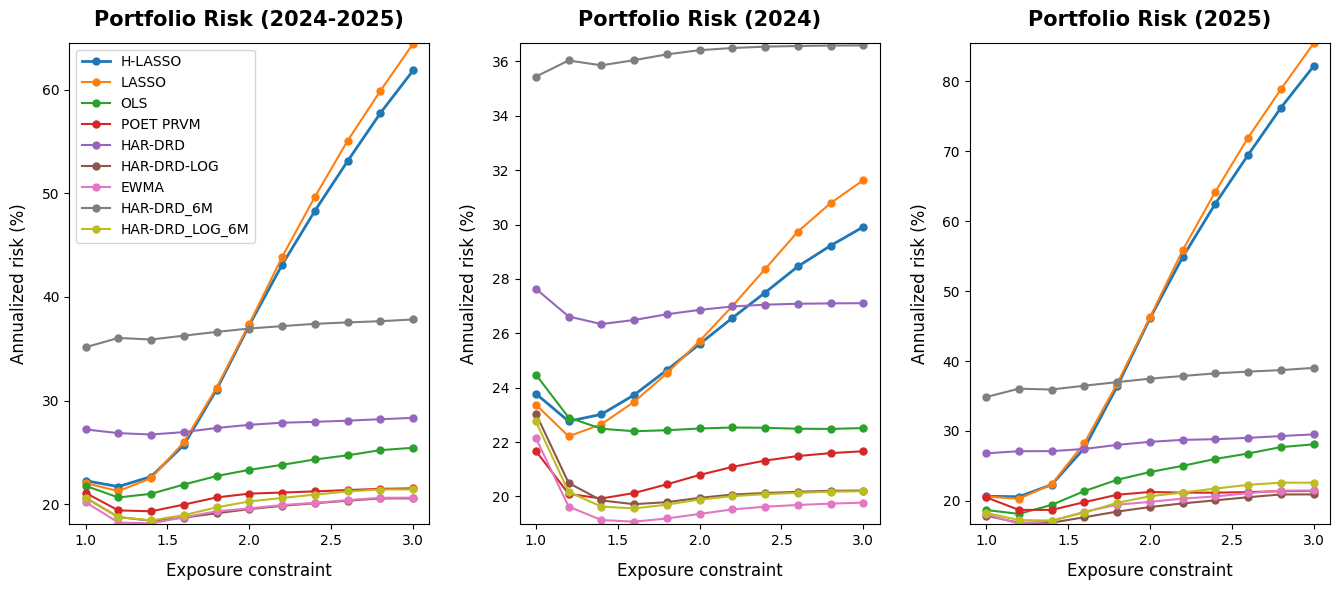

In [103]:
# Load Risks and Plot

c0_values = np.linspace(1, 3, 11)

risks_list = [
    risks_H_LASSO,
    risks_LASSO,
    risks_OLS,
    risks_POET,
    risks_HAR_DRD,
    risks_HAR_DRD_LOG,
    risks_EWMA,
    risks_HAR_DRD_n_180,
    risks_HAR_DRD_LOG_n_180
]

labels = [
    "H-LASSO",
    "LASSO",
    "OLS",
    "POET PRVM",
    "HAR-DRD",
    "HAR-DRD-LOG",
    "EWMA",
    "HAR-DRD_6M",
    "HAR-DRD_LOG_6M"
]

years = sorted(mask_dict.keys())

risk_sets = plot_portfolio_risk_by_years(
    c0_values=c0_values,
    risks_list=risks_list,
    labels=labels,
    years=years,
    mask_dict=mask_dict,
    one_year=365,
    # filename="portfolio_risk_crypto.pdf",
    # save_dir=FIVAR_OUTPUT_DIR
)

# MSPE/QLIKE

In [104]:
# MSPE / QLIKE comparison on the continuous PRVM forecast

pred_dict = {
    "POET PRVM":   pred_POET,
    "OLS":         pred_OLS,
    "EWMA":        pred_EWMA,
    "LASSO":       pred_LASSO,
    "H-LASSO":     pred_H_LASSO,
    "HAR-DRD":     pred_HAR_DRD,
    "HAR-DRD-LOG": pred_HAR_DRD_LOG,
    "HAR-DRD-6M":  pred_HAR_DRD_n_180,
    "HAR-DRD-LOG-6M":  pred_HAR_DRD_LOG_n_180
}

start_year = min(mask_dict.keys())
end_year   = max(mask_dict.keys())

df_mspe, df_qlike = make_df_from_preds_by_years(
    true_matrices=true_PRVM,
    pred_dict=pred_dict,
    start_year=start_year,
    end_year=end_year,
    mask_dict={k: pd.Series(v) for k, v in mask_dict.items()}
)

print("MSPE x 1e1")
print(df_mspe.round(4))
print()
print("QLIKE x 1e-3")
print(df_qlike.round(4))

MSPE x 1e1
           POET PRVM      OLS    EWMA    LASSO  H-LASSO  HAR-DRD  HAR-DRD-LOG  \
2024-2025     1.8283   9.7228  1.4050   9.3284   1.3537   1.3116       1.2457   
2024          1.3943   1.1324  1.1541   1.1367   1.1440   1.0743       1.0615   
2025          2.2624  18.3132  1.6559  17.5200   1.5633   1.5489       1.4300   

           HAR-DRD-6M  HAR-DRD-LOG-6M  
2024-2025      1.3804          1.2561  
2024           1.1625          1.0708  
2025           1.5984          1.4414  

QLIKE x 1e-3
           POET PRVM     OLS    EWMA   LASSO  H-LASSO  HAR-DRD  HAR-DRD-LOG  \
2024-2025    -1.1451 -0.8132 -1.1871  0.4725   0.0352  -0.2721      -1.1928   
2024         -1.1362 -1.0156 -1.1776 -0.0650  -0.5302  -0.5057      -1.1811   
2025         -1.1539 -0.6108 -1.1966  1.0101   0.6007  -0.0385      -1.2046   

           HAR-DRD-6M  HAR-DRD-LOG-6M  
2024-2025      2.6060         -1.1905  
2024           1.9835         -1.1802  
2025           3.2285         -1.2008  


# Test code

In [ ]:
# 생략